### Question 1

In [214]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [215]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

# Keep execution logs clean
warnings.filterwarnings('ignore', category=FutureWarning)
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# =====================================================================
# STEP 1: Load and Prepare Dataset (Fixed Capitalization)
# =====================================================================
df_raw = pd.read_csv('Youth_DASS_And_TIPI_Dataset_Cleaned_With_Calculated_And_Categorized_Columns.csv')
df = df_raw.copy()
# FIXED: Capitalized to match the exact row values in your CSV
encoder = OrdinalEncoder(categories=[['Moderate', 'Severe', 'Extremely Severe']])
df['depression_encoded'] = encoder.fit_transform(df[['Depression_Severity']]).astype(int)

# Independent Features (Inputs: X)
X = df[['Anxiety_Score', 'Stress_Score', 'Extraversion', 'Agreeableness', 
        'Conscientiousness', 'Emotional_Stability', 'Openness']]

# Target Variable (Output: y)
y = df['depression_encoded']

# Stratified Split (Tracking the original dataframe row indices)
X_train, X_test, y_train, y_test, _, indices_test = train_test_split(
    X, y, df.index, test_size=0.3, random_state=42, stratify=y
)

# Normalize features to 0.0 - 1.0 range
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# STEP 2: Train Multinomial Logistic Regression Model
# =====================================================================
model = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

# Generate predictions and raw probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# FIXED: Capitalized to maintain a perfect sync with the encoder map
backend_classes = ['Moderate', 'Severe', 'Extremely Severe']

# FIXED: Keys mapped to match capitalized text
dashboard_risk_map = {
    'Moderate': 'Low Possibility of MDD',
    'Severe': 'Medium Possibility of MDD',
    'Extremely Severe': 'High Possibility of MDD'
}

# =====================================================================
# STEP 3: Print Unified Diagnostics with Exact Column Matching
# =====================================================================
print("================================================================================================")
print("             CAMPUS DASHBOARD TRIAGE GENERATOR (EXACT DEPRESSION_SCORE ALIGNMENT)               ")
print("================================================================================================")
print(f"{'Student ID':<12} | {'Depression_Score':<18} | {'P(Low)':<10} | {'P(Medium)':<10} | {'P(High)':<10} | {'Dashboard Output UI Flag'}")
print("-" * 112)

# Loop to display the first 100 students in the test partition
for idx, (original_df_index, pred_idx, prob_array) in enumerate(zip(indices_test, y_pred, y_prob)):
    if idx >= 100: 
        break
        
    if idx > 0 and idx % 20 == 0:
        print(f"--- BATCH BREAK [Records {idx-20} to {idx}] ----------------------------------------------------")
        
    # Pull the exact continuous point score column from your spreadsheet
    raw_depression_score = df.loc[original_df_index, 'Depression_Score']
    
    # Grab clinical label and map to user-friendly risk text
    clinical_label = backend_classes[pred_idx]
    dashboard_ui_flag = dashboard_risk_map[clinical_label]
    
    print(f"Student #{idx:<4} | {raw_depression_score:<18.2f} | {prob_array[0]:<10.4f} | {prob_array[1]:<10.4f} | {prob_array[2]:<10.4f} | -> {dashboard_ui_flag}")

print("================================================================================================")

ValueError: Found unknown categories ['Mild', 'Normal'] in column 0 during fit

In [200]:
# Load and Prepare Dataset
df_raw = pd.read_csv('Youth_DASS_And_TIPI_Dataset_Cleaned_With_Calculated_And_Categorized_Columns.csv')
df = df_raw.copy()
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,TIPI4_R_Normalized,TIPI6_R_Normalized,TIPI8_R_Normalized,TIPI10_R_Normalized,Extraversion_Normalized,Agreeableness_Normalized,Conscientiousness_Normalized,Emotional_Stability_Normalized,Openness_Normalized,TIPI_Total_Normalized
0,3,3,1,3,3,3,3,3,1,0,...,0.0000,0.0000,0.2857,0.8571,0.0714,0.5652,0.6429,0.0769,0.9286,0.5938
1,3,0,1,2,3,3,2,3,2,1,...,0.0000,0.5000,0.0000,0.2857,0.6429,0.5652,0.2857,0.0769,0.5000,0.6875
2,2,0,3,0,3,2,0,2,1,3,...,1.0000,0.1667,0.2857,0.7143,0.2143,0.3913,0.2857,0.6154,0.7143,0.2500
3,1,1,2,3,3,1,3,3,3,2,...,0.2000,0.3333,0.1429,0.5714,0.2857,0.3913,0.2857,0.3077,0.6429,0.4375
4,0,0,1,0,2,0,0,2,2,1,...,1.0000,0.0000,0.7143,0.0000,0.1429,0.9130,0.7857,0.9231,0.5000,0.5312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27172,3,3,3,2,3,3,2,2,3,3,...,0.0000,0.1667,0.4286,0.1429,0.1429,0.4783,0.5714,0.2308,0.2857,0.5312
27173,2,3,1,1,1,3,3,1,0,2,...,0.4000,0.6667,0.7143,0.0000,0.7143,0.3913,0.6429,0.5385,0.4286,0.5938
27174,1,0,2,1,2,1,0,2,0,3,...,0.4000,0.3333,0.5714,0.1429,0.2857,0.6522,0.5000,0.3846,0.5000,0.3438
27175,2,3,2,3,2,3,3,3,2,3,...,0.0000,0.1667,0.0000,0.4286,0.3571,0.3043,0.3571,0.3077,0.5000,0.6562


In [201]:
# Explicitly encode the 3-category target variable matching the clinical progression
encoder = OrdinalEncoder(categories=[['Moderate', 'Severe', 'Extremely Severe']])
df['Depression_Encoded'] = encoder.fit_transform(df[['Depression_Severity']]).astype(int)

# Select features representing DASS scoring components, core TIPI personality traits and 5 demographic data
X = df[['Anxiety_Score', 'Stress_Score', 'Extraversion', 'Agreeableness', 
        'Conscientiousness', 'Emotional_Stability', 'Openness',
        'Gender', 'Age', 'Education', 'Married', 'Family_Size']]
y = df['Depression_Encoded'] # 0 = Moderate, 1 = Severe, 2 = Extremely Severe

In [210]:
# Stratified Train-Test Split
# Splitting 70% training and 30% testing, stratifying to preserve target class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [203]:
# Data Preparation (Min-Max Normalization)
# Initializing Min-Max scaler to standardize all values strictly to a 0-1 range
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [204]:
# Initialize and Train Multinomial Logistic Regression
# Setting high max_iter ceiling to guarantee error convergence on the dataset
model = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [205]:
# Generate Test Predictions and Soft Probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled) # Generates continuous 3-column float array

In [206]:
# Internal clinical labels used by the machine learning algorithm
backend_classes = ['Moderate', 'Severe', 'Extremely Severe']

In [207]:
dashboard_risk_map = {
    'Moderate': 'Low Possibility of MDD',
    'Severe': 'Medium Possibility of MDD',
    'Extremely Severe': 'High Possibility of MDD'
}

In [208]:
# =====================================================================
# STEP 4: Print DASS-42 Unified Diagnostics
# =====================================================================
print("==========================================================================================")
print("             DASS-42 CAMPUS DASHBOARD TRIAGE GENERATOR (FIRST 20 STUDENTS)                ")
print("==========================================================================================")
print(f"{'Student ID':<12} | {'DASS-42 Score':<15} | {'P(Low)':<10} | {'P(Medium)':<10} | {'P(High)':<10} | {'Dashboard Output UI Flag'}")
print("-" * 105)

for idx, (original_df_index, pred_idx, prob_array) in enumerate(zip(indices_test, y_pred, y_prob)):
    if idx >= 20: 
        break
        
    # Get raw DASS-42 score (Ranges up to 42 points)
    dass_42_score = df.loc[original_df_index, 'Depression_Score']
    
    clinical_label = backend_classes[pred_idx]
    dashboard_ui_flag = dashboard_risk_map[clinical_label]
    
    print(f"Student #{idx:<4} | {dass_42_score:<15.2f} | {prob_array[0]:<10.4f} | {prob_array[1]:<10.4f} | {prob_array[2]:<10.4f} | -> {dashboard_ui_flag}")

print("==========================================================================================")

             DASS-42 CAMPUS DASHBOARD TRIAGE GENERATOR (FIRST 20 STUDENTS)                
Student ID   | DASS-42 Score   | P(Low)     | P(Medium)  | P(High)    | Dashboard Output UI Flag
---------------------------------------------------------------------------------------------------------


NameError: name 'indices_test' is not defined

In [197]:
# Look at the exact probability split vs the final hard prediction for the first 5 students
for i in range(100):
    print(f"Student #{i} | y_prob Split: {y_prob[i]} | Winning y_pred Label: {y_pred[i]}")

Student #0 | y_prob Split: [0.0238 0.1597 0.8164] | Winning y_pred Label: 2
Student #1 | y_prob Split: [0.025  0.1451 0.8299] | Winning y_pred Label: 2
Student #2 | y_prob Split: [0.     0.0021 0.9979] | Winning y_pred Label: 2
Student #3 | y_prob Split: [0.1224 0.3087 0.5688] | Winning y_pred Label: 2
Student #4 | y_prob Split: [0.5499 0.3315 0.1187] | Winning y_pred Label: 0
Student #5 | y_prob Split: [0.65   0.2467 0.1033] | Winning y_pred Label: 0
Student #6 | y_prob Split: [0.4925 0.3611 0.1464] | Winning y_pred Label: 0
Student #7 | y_prob Split: [0.0017 0.0419 0.9564] | Winning y_pred Label: 2
Student #8 | y_prob Split: [0.0013 0.0388 0.9599] | Winning y_pred Label: 2
Student #9 | y_prob Split: [0.0792 0.279  0.6418] | Winning y_pred Label: 2
Student #10 | y_prob Split: [0.0001 0.0111 0.9888] | Winning y_pred Label: 2
Student #11 | y_prob Split: [0.085  0.2435 0.6715] | Winning y_pred Label: 2
Student #12 | y_prob Split: [0.0179 0.133  0.8491] | Winning y_pred Label: 2
Student #

In [198]:
np.set_printoptions(suppress=True, precision=3)
print(list(y_prob))

[array([0.024, 0.16 , 0.816]), array([0.025, 0.145, 0.83 ]), array([0.   , 0.002, 0.998]), array([0.122, 0.309, 0.569]), array([0.55 , 0.331, 0.119]), array([0.65 , 0.247, 0.103]), array([0.493, 0.361, 0.146]), array([0.002, 0.042, 0.956]), array([0.001, 0.039, 0.96 ]), array([0.079, 0.279, 0.642]), array([0.   , 0.011, 0.989]), array([0.085, 0.243, 0.672]), array([0.018, 0.133, 0.849]), array([0.   , 0.024, 0.976]), array([0.   , 0.017, 0.983]), array([0.004, 0.066, 0.931]), array([0.76 , 0.195, 0.045]), array([0.001, 0.033, 0.966]), array([0.008, 0.096, 0.896]), array([0.   , 0.014, 0.986]), array([0.001, 0.042, 0.956]), array([0.004, 0.075, 0.921]), array([0.131, 0.287, 0.582]), array([0.   , 0.007, 0.993]), array([0.548, 0.32 , 0.132]), array([0.699, 0.232, 0.069]), array([0.002, 0.057, 0.941]), array([0.068, 0.239, 0.694]), array([0.   , 0.005, 0.995]), array([0.002, 0.056, 0.942]), array([0.018, 0.144, 0.838]), array([0.056, 0.24 , 0.703]), array([0.004, 0.063, 0.933]), array([0.

In [161]:
max(y_prob), min(y_prob)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [155]:
print(y_pred)

[2 2 2 ... 2 2 2]


In [162]:
print("--- Pipeline Execution Complete ---")
print(f"Full Dataset Shape: {df.shape}")
print(f"Test Features Shape: {X_test_scaled.shape} | Test Probabilities Shape: {y_prob.shape}")

--- Pipeline Execution Complete ---
Full Dataset Shape: (27177, 160)
Test Features Shape: (5436, 12) | Test Probabilities Shape: (5436, 3)


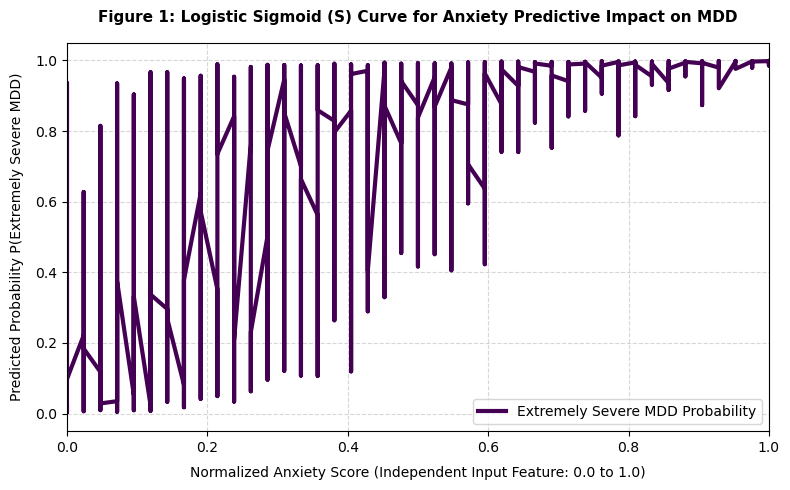

In [168]:
plt.figure(figsize=(8, 5))

# Flatten columns to 1D arrays
anxiety_feature = X_test_scaled[:, 0].flatten()       # X-Axis (Input Engine)
extremely_severe_prob = y_prob[:, 2].flatten()        # Y-Axis (MDD Probability Output)

# Bind columns together in a temporary DataFrame to preserve row pairing during sorting
s_curve_df = pd.DataFrame({
    'Anxiety': anxiety_feature,
    'MDD_Probability': extremely_severe_prob
}).sort_values(by='Anxiety') # Forces sequential plotting from 0.0 to 1.0

plt.plot(
    s_curve_df['Anxiety'], 
    s_curve_df['MDD_Probability'], 
    color='#440154', 
    linewidth=3, 
    label='Extremely Severe MDD Probability'
)

plt.title('Figure 1: Logistic Sigmoid (S) Curve for Anxiety Predictive Impact on MDD', fontsize=11, weight='bold', pad=15)
plt.xlabel('Normalized Anxiety Score (Independent Input Feature: 0.0 to 1.0)', fontsize=10, labelpad=8)
plt.ylabel('Predicted Probability P(Extremely Severe MDD)', fontsize=10, labelpad=8)
plt.xlim(0.0, 1.0)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

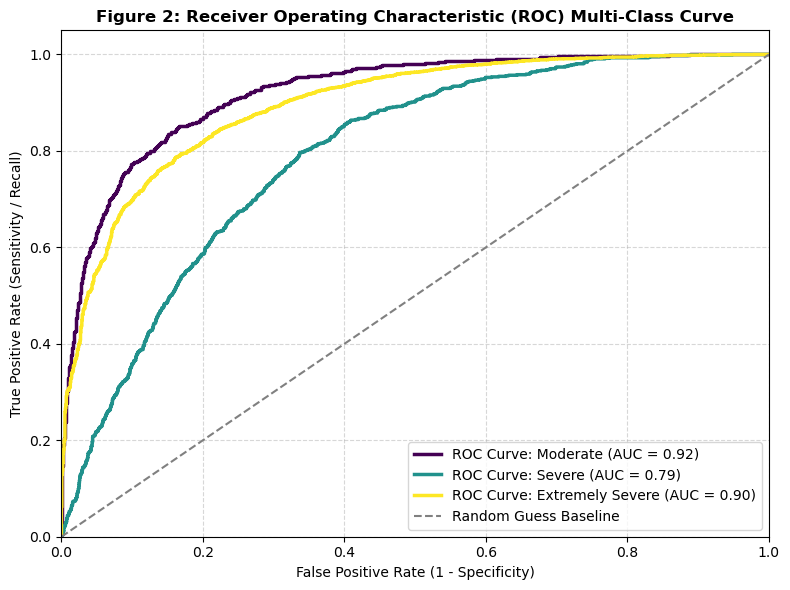

In [167]:
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
class_names = ['Moderate', 'Severe', 'Extremely Severe']
colors = ['#440154', '#21918c', '#fde725'] # Cohesive Viridis palette colors

plt.figure(figsize=(8, 6))

# Calculate ROC and AUC for each individual class tier
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr, 
        color=colors[i], 
        lw=2.5, 
        label=f'ROC Curve: {class_names[i]} (AUC = {roc_auc:.2f})'
    )

# Plot the diagonal baseline representing a purely random guess classifier (AUC = 0.50)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess Baseline')

plt.title('Figure 2: Receiver Operating Characteristic (ROC) Multi-Class Curve', fontsize=12, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Question 2

In [169]:
# Extract and print performance parameters 
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("=============================================")
print("     QUESTION 2(a) MODEL METRIC OUTPUTS     ")
print("=============================================")
print(f"Overall Classification Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("\nRaw 3x3 Confusion Matrix Grid:")
print(conf_matrix)
print("\nComprehensive Classification Metrics per Tier:")
print(classification_report(y_test, y_pred, target_names=['Moderate', 'Severe', 'Extremely Severe']))

     QUESTION 2(a) MODEL METRIC OUTPUTS     
Overall Classification Accuracy: 0.7838 (78.38%)

Raw 3x3 Confusion Matrix Grid:
[[ 479   65  168]
 [ 198  103  580]
 [  91   73 3679]]

Comprehensive Classification Metrics per Tier:
                  precision    recall  f1-score   support

        Moderate       0.62      0.67      0.65       712
          Severe       0.43      0.12      0.18       881
Extremely Severe       0.83      0.96      0.89      3843

        accuracy                           0.78      5436
       macro avg       0.63      0.58      0.57      5436
    weighted avg       0.74      0.78      0.74      5436



### Question 3

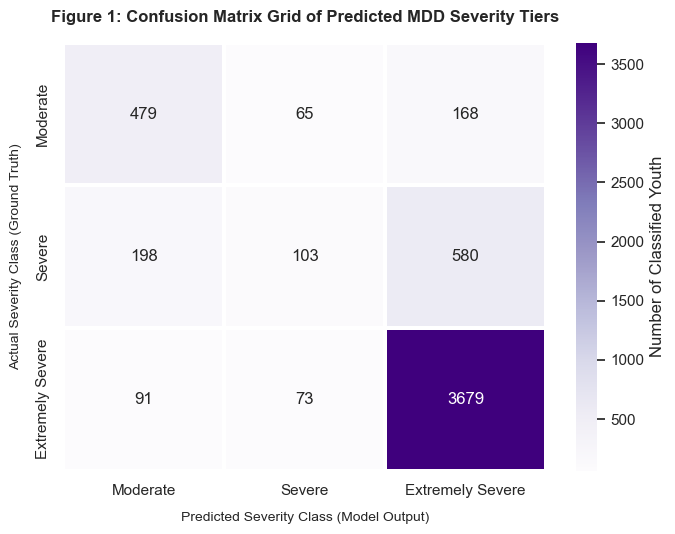

In [170]:
# Create a visually structured confusion matrix heatmap
plt.figure(figsize=(7, 5.5))
sns.set_theme(style='white')

# Utilizing the colorblind-accessible 'Purples' spectrum to maintain layout clarity
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    linewidths=1.5,
    cbar_kws={'label': 'Number of Classified Youth'},
    xticklabels=['Moderate', 'Severe', 'Extremely Severe'],
    yticklabels=['Moderate', 'Severe', 'Extremely Severe']
)

plt.title('Figure 1: Confusion Matrix Grid of Predicted MDD Severity Tiers', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Severity Class (Model Output)', fontsize=10, labelpad=10)
plt.ylabel('Actual Severity Class (Ground Truth)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

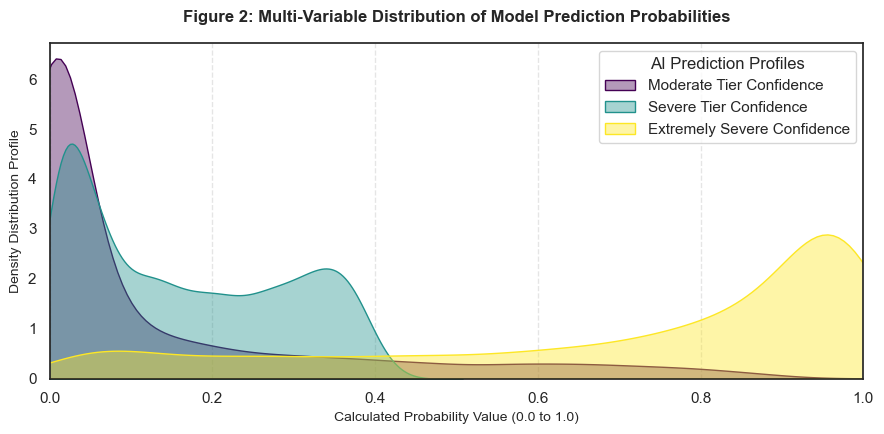

In [171]:
# Construct an advanced multi-variable density plot mapping class probabilities
prob_df = pd.DataFrame(y_prob, columns=['Moderate Probability', 'Severe Probability', 'Extremely Severe Probability'])

plt.figure(figsize=(9, 4.5))

# Plot kernel density estimators for each predicted classification boundary
sns.kdeplot(data=prob_df['Moderate Probability'], fill=True, color='#440154', label='Moderate Tier Confidence', alpha=0.4)
sns.kdeplot(data=prob_df['Severe Probability'], fill=True, color='#21918c', label='Severe Tier Confidence', alpha=0.4)
sns.kdeplot(data=prob_df['Extremely Severe Probability'], fill=True, color='#fde725', label='Extremely Severe Confidence', alpha=0.4)

plt.title('Figure 2: Multi-Variable Distribution of Model Prediction Probabilities', fontsize=12, pad=15, weight='bold')
plt.xlabel('Calculated Probability Value (0.0 to 1.0)', fontsize=10)
plt.ylabel('Density Distribution Profile', fontsize=10)
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='AI Prediction Profiles', loc='upper right')
plt.tight_layout()
plt.show()